# Flujo del proyecto

1. Analisis exploratorio de los datos (EDA)
2. Preprocesamiento (Limpiza, calidad, Ingenieria de caracteristicas)
3. Entrenamiento de los modelos: Cuantos? Cuales? -> Depende las metricas
4. Evaluación (Comparamos las metricas)
5. Tuning hiperparámetros
6. Modelo final -> Producción

1. Importar/cargar

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sn
import seaborn as sns
from adjustText import adjust_text
from sklearn.datasets import load_wine
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier, BaggingClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.linear_model import RidgeClassifier, PassiveAggressiveClassifier
from sklearn.dummy import DummyClassifier

warnings.filterwarnings('ignore')

In [2]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (10, 10)
plt.rcParams['font.size'] = 12


In [3]:
# load wine()
wine = load_wine()
wine

{'data': array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
         1.065e+03],
        [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
         1.050e+03],
        [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
         1.185e+03],
        ...,
        [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
         8.350e+02],
        [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
         8.400e+02],
        [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
         5.600e+02]], shape=(178, 13)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [4]:
df = pd.DataFrame(data=wine.data, columns=wine.feature_names)
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [5]:
df['target'] = wine.target
df['target']

0      0
1      0
2      0
3      0
4      0
      ..
173    2
174    2
175    2
176    2
177    2
Name: target, Length: 178, dtype: int64

In [6]:
df['target_name'] = df['target'].map({i: name for i, name in enumerate(wine.target_names)})
df['target_name']

0      class_0
1      class_0
2      class_0
3      class_0
4      class_0
        ...   
173    class_2
174    class_2
175    class_2
176    class_2
177    class_2
Name: target_name, Length: 178, dtype: str

In [7]:
print("Dataset: Wine")
print(f" Muestras: {df.shape[0]}")
print(f" Características/Features: {df.shape[1] - 2}")
print(f" Clases: {list(wine.target_names)}")
print(f" Descripción: {wine.DESCR}")

Dataset: Wine
 Muestras: 178
 Características/Features: 13
 Clases: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]
 Descripción: .. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                 

2. Analisis

In [8]:
df.tail()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.7,0.64,1.74,740.0,2,class_2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.3,0.70,1.56,750.0,2,class_2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.2,0.59,1.56,835.0,2,class_2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.3,0.60,1.62,840.0,2,class_2
177,14.13,4.10,2.74,24.5,96.0,2.05,0.76,0.56,1.35,9.2,0.61,1.60,560.0,2,class_2


In [9]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


In [10]:
df.sample()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
73,12.99,1.67,2.6,30.0,139.0,3.3,2.89,0.21,1.96,3.35,1.31,3.5,985.0,1,class_1


In [11]:
df.describe(include='all').round()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
count,178.0,178.0,178.0,178.0,178.0,178.0,178.0,178.0,178.0,178.0,178.0,178.0,178.0,178.0,178
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,class_1
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71
mean,13.0,2.0,2.0,19.0,100.0,2.0,2.0,0.0,2.0,5.0,1.0,3.0,747.0,1.0,NaN
std,1.0,1.0,0.0,3.0,14.0,1.0,1.0,0.0,1.0,2.0,0.0,1.0,315.0,1.0,NaN
min,11.0,1.0,1.0,11.0,70.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,278.0,0.0,NaN
25%,12.0,2.0,2.0,17.0,88.0,2.0,1.0,0.0,1.0,3.0,1.0,2.0,500.0,0.0,NaN
50%,13.0,2.0,2.0,20.0,98.0,2.0,2.0,0.0,2.0,5.0,1.0,3.0,674.0,1.0,NaN
75%,14.0,3.0,3.0,22.0,107.0,3.0,3.0,0.0,2.0,6.0,1.0,3.0,985.0,2.0,NaN


In [12]:
print(df.isnull().sum().to_string())

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
target_name                     0


In [13]:
print(df.isna().sum().to_string())

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
target_name                     0


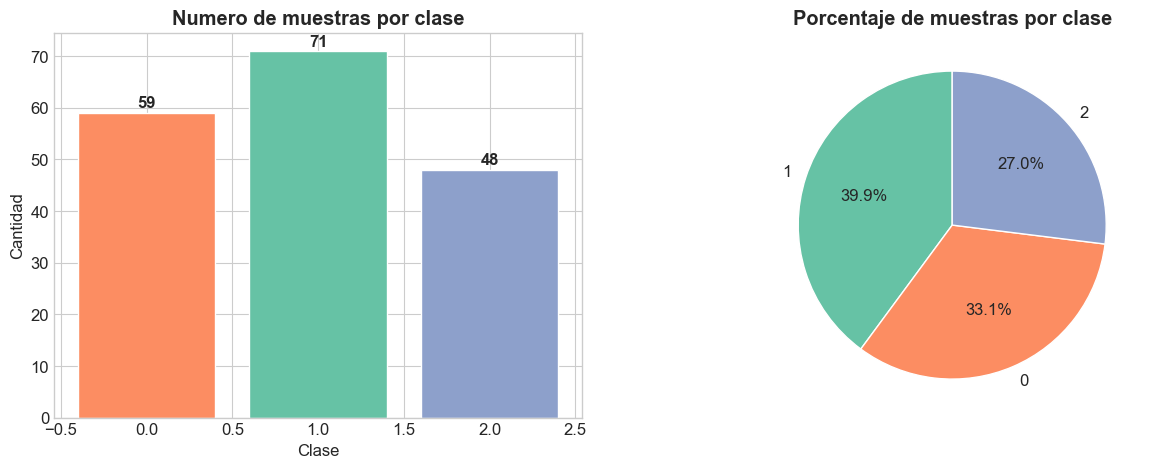

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
#Conteo
class_counts = df['target'].value_counts()
axes[0].bar(class_counts.index, class_counts.values, color=sns.color_palette('Set2', 3))
axes[0].set_title('Numero de muestras por clase', fontweight='bold')
axes[0].set_ylabel('Cantidad')
axes[0].set_xlabel('Clase')

for bar in axes[0].patches:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width() / 2, height + 1, int(height), ha='center', fontweight='bold')

# Porcentaje
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('Set2', 3))
axes[1].set_title('Porcentaje de muestras por clase', fontweight='bold')
plt.show()

In [15]:
for bar in axes[0].patches:
    print(bar)

Rectangle(xy=(0.6, 0), width=0.8, height=71, angle=0)
Rectangle(xy=(-0.4, 0), width=0.8, height=59, angle=0)
Rectangle(xy=(1.6, 0), width=0.8, height=48, angle=0)


In [16]:
# Distribución de caracteristicas o features x clase
feature_to_plot = ['alcohol', 'malic_acid', 'flavanoids', 'color_intensity', 'od280/od315_of_diluted_wines', 'proline']

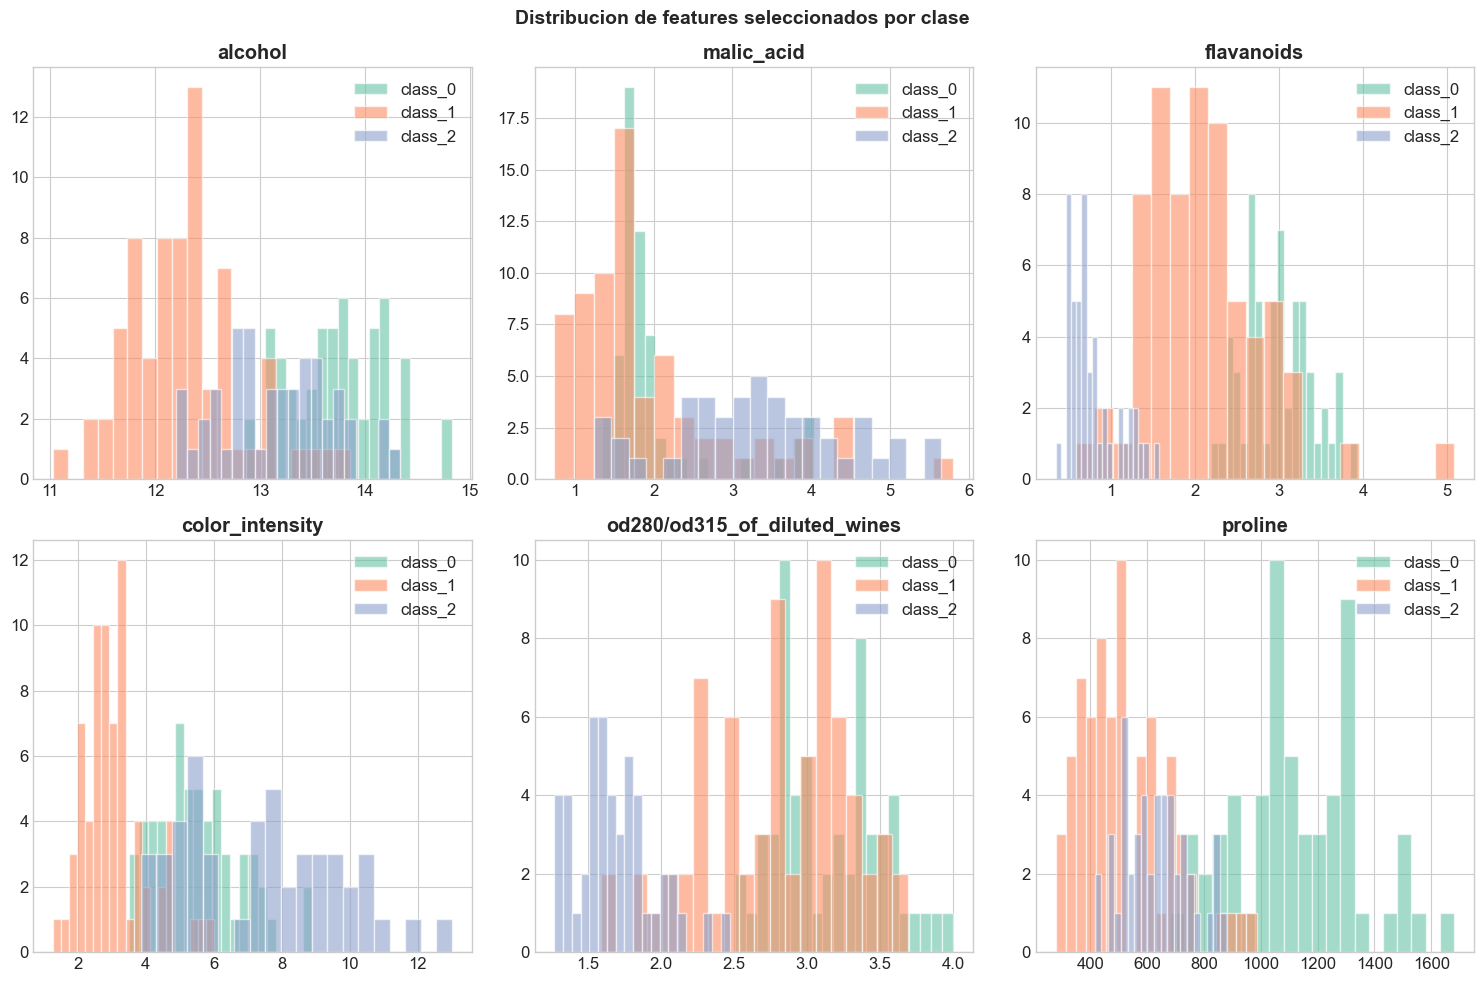

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(feature_to_plot):
    for cls in wine.target_names:
        subset = df[df['target_name'] == cls][feature]
        axes[i].hist(subset, bins=20, label=cls, alpha=0.6)
        axes[i].set_title(feature, fontweight='bold')
        axes[i].legend(fontsize=12)
plt.suptitle('Distribucion de features seleccionados por clase', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

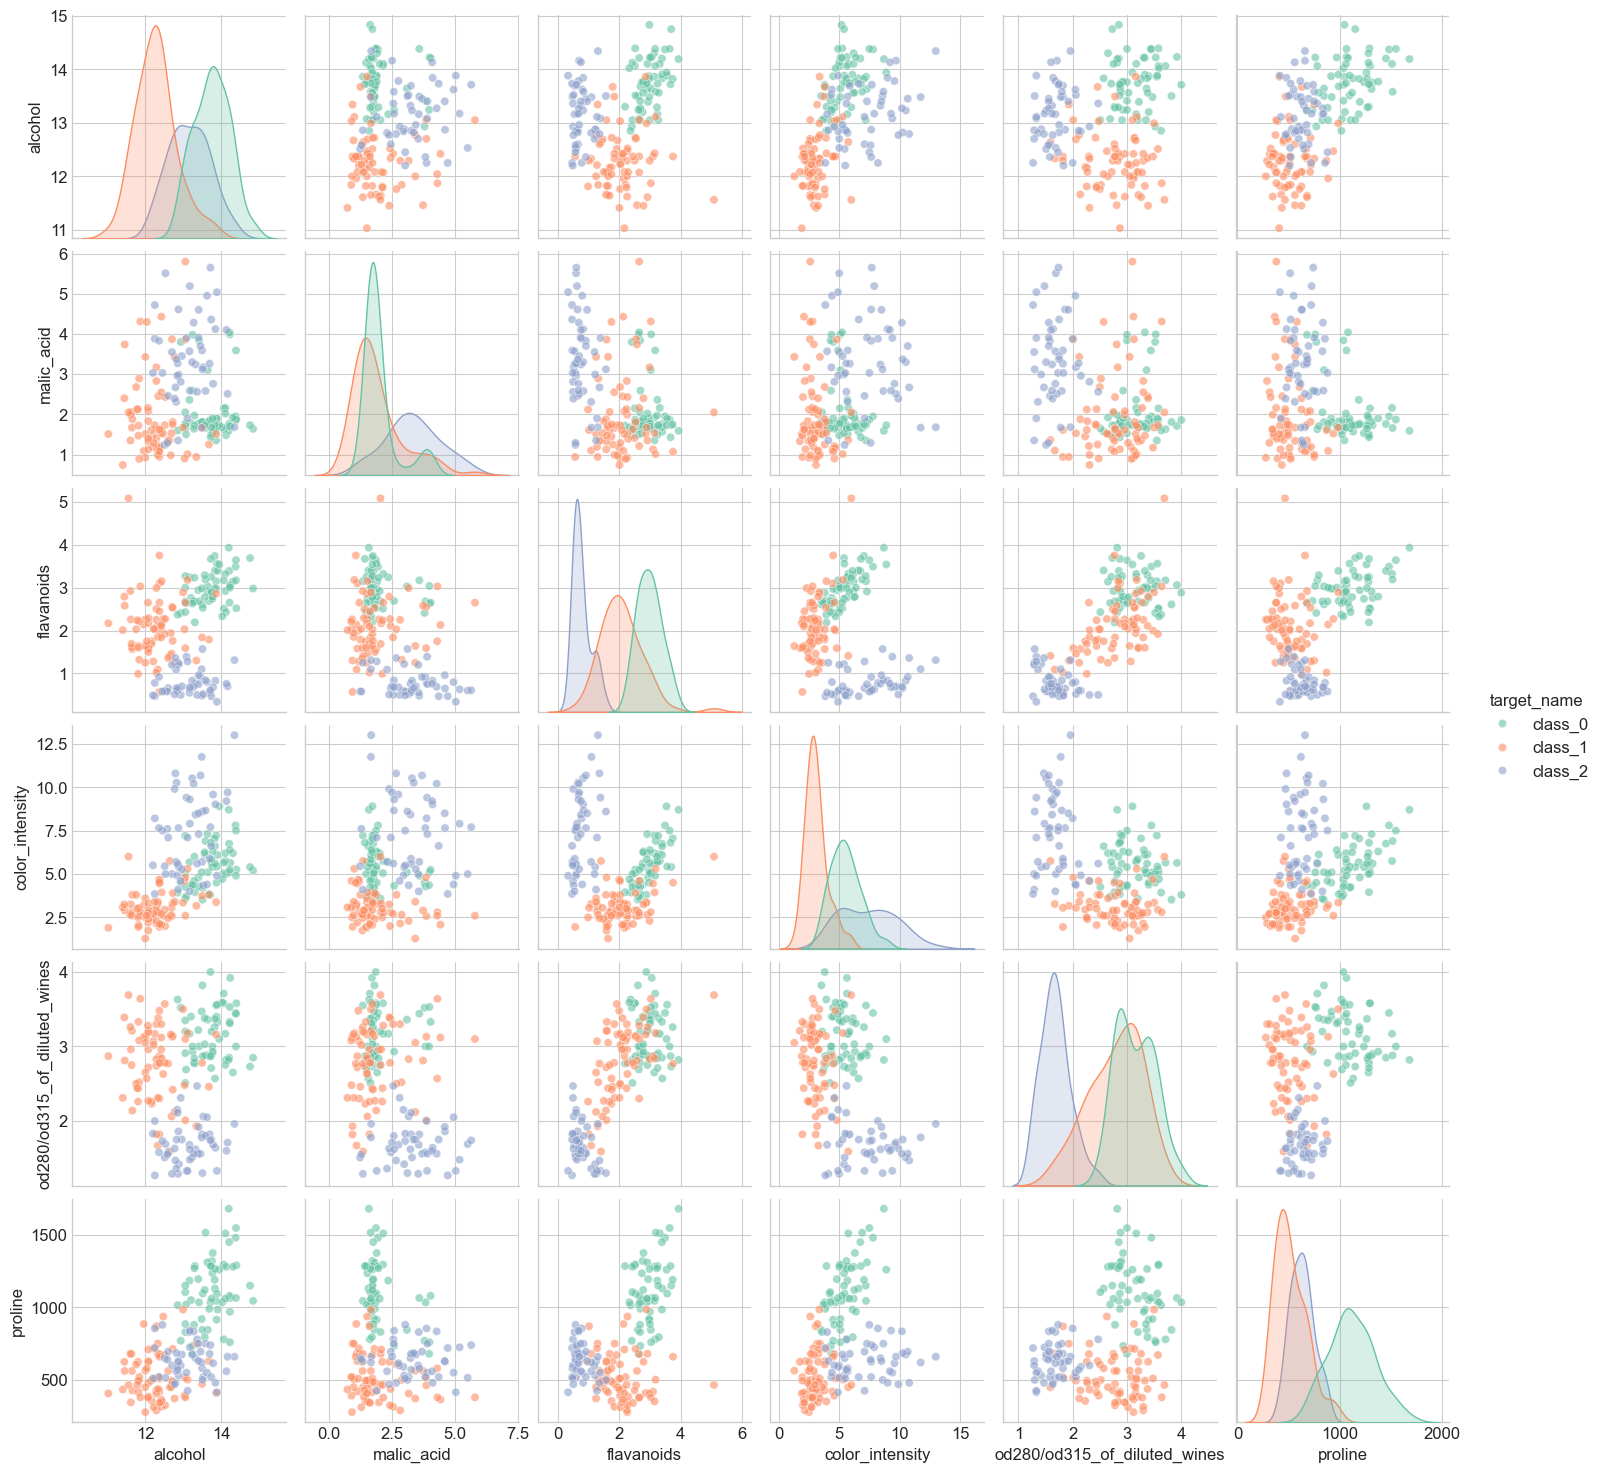

In [18]:
graphic = sns.pairplot(df[feature_to_plot + ['target_name']], hue='target_name', plot_kws={'alpha': 0.6})

In [19]:
X_scaled = pd.DataFrame(StandardScaler().fit_transform(df[wine.feature_names]), columns=wine.feature_names)
X_scaled

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,0.876275,2.974543,0.305159,0.301803,-0.332922,-0.985614,-1.424900,1.274310,-0.930179,1.142811,-1.392758,-1.231206,-0.021952
174,0.493343,1.412609,0.414820,1.052516,0.158572,-0.793334,-1.284344,0.549108,-0.316950,0.969783,-1.129518,-1.485445,0.009893
175,0.332758,1.744744,-0.389355,0.151661,1.422412,-1.129824,-1.344582,0.549108,-0.422075,2.224236,-1.612125,-1.485445,0.280575
176,0.209232,0.227694,0.012732,0.151661,1.422412,-1.033684,-1.354622,1.354888,-0.229346,1.834923,-1.568252,-1.400699,0.296498


<Axes: >

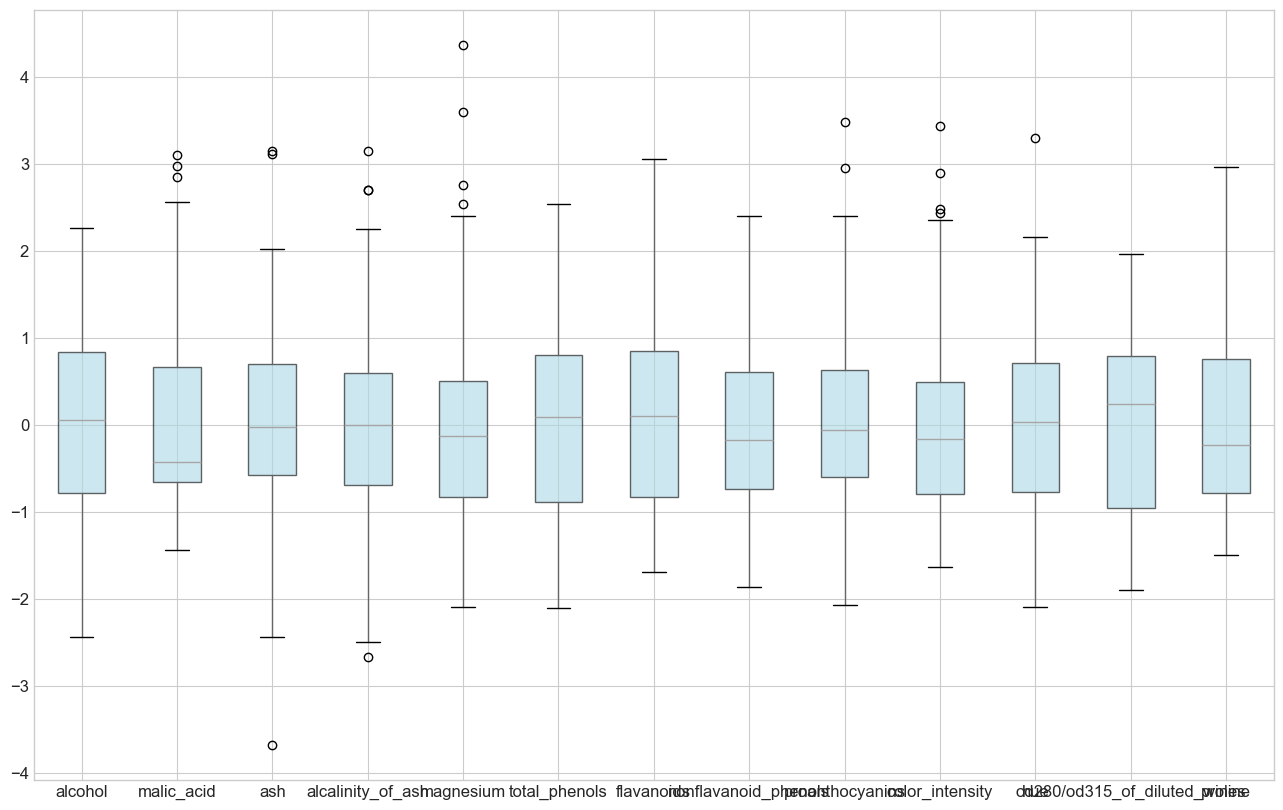

In [20]:
fig, ax = plt.subplots(figsize=(16, 10))

X_scaled.boxplot(ax=ax, vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue', alpha=0.6))

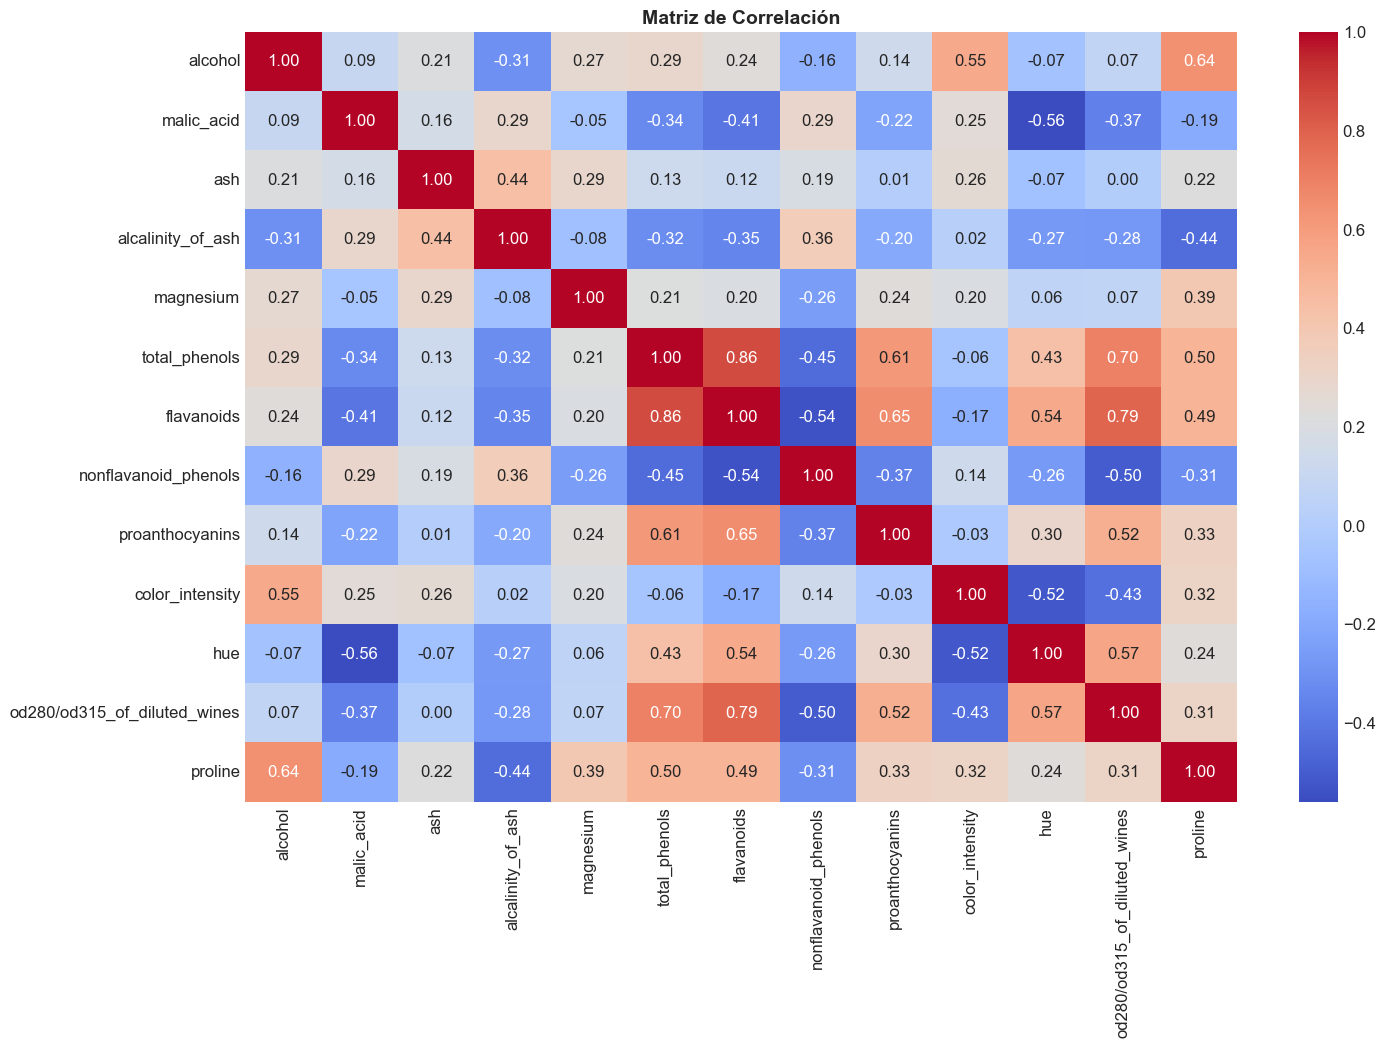

In [21]:
fig, ax = plt.subplots(figsize=(16, 10))
corr = df[wine.feature_names].corr()
sn.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title('Matriz de Correlación', fontweight='bold', fontsize=14)
plt.show()

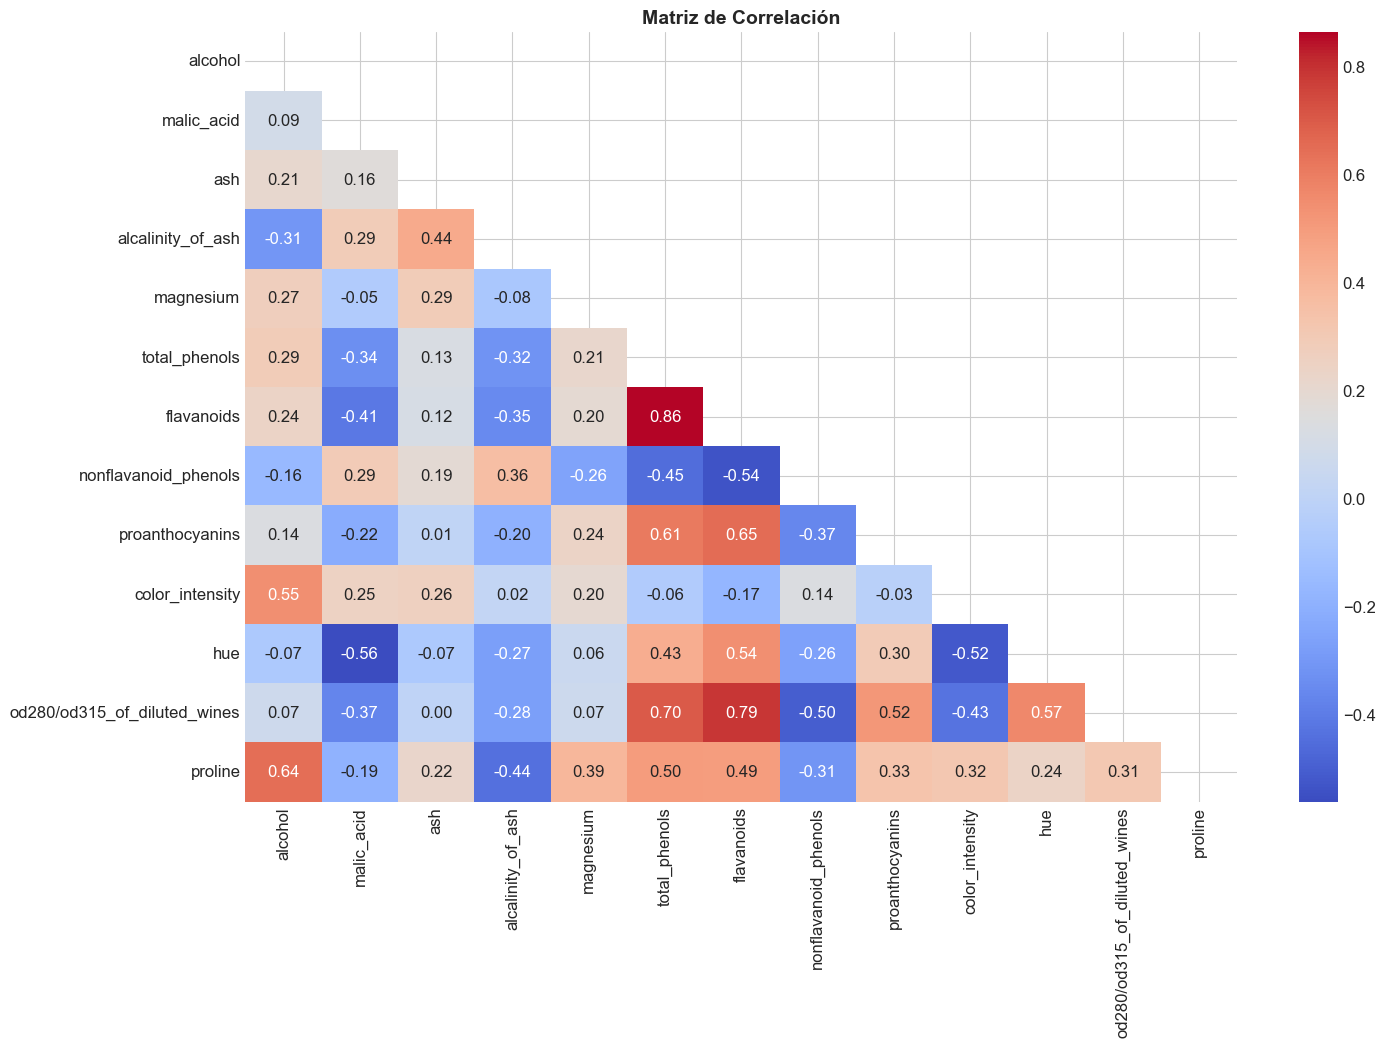

In [22]:
fig, ax = plt.subplots(figsize=(16, 10))
corr = df[wine.feature_names].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  #Simetria para ver Multicolinealidad
sn.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax, mask=mask)
ax.set_title('Matriz de Correlación', fontweight='bold', fontsize=14)
plt.show()

! Multicolinealidad (Menor a -80 o Mayor a 80) Puede generar redundacia en ciertos modelos

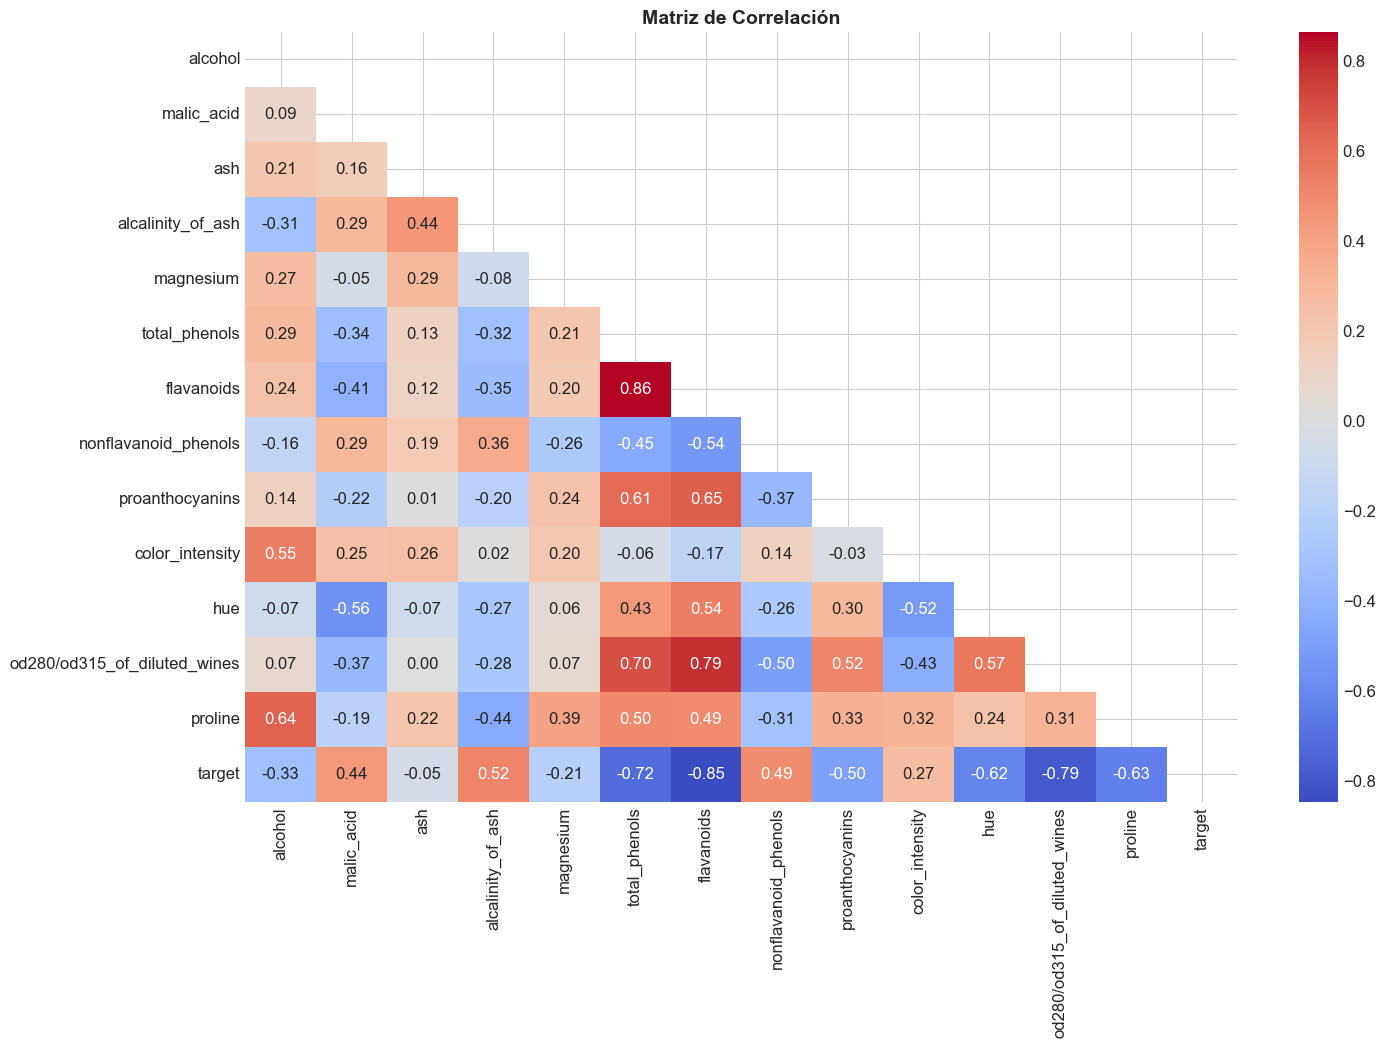

In [23]:
fig, ax = plt.subplots(figsize=(16, 10))
corr = df[wine.feature_names+['target']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  #Simetria
sn.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax, mask=mask)
ax.set_title('Matriz de Correlación', fontweight='bold', fontsize=14)
plt.show()

# Entrenamiento

In [24]:
X = df[wine.feature_names].values  # Independiente
y = df['target_name'].values  # Dependiente

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5, stratify=y)

In [26]:
print(f'Entrenamiento: {X_train.shape[0]} muestras {X_train.shape[0] / len(X) * 100:.0f}%')

Entrenamiento: 142 muestras 80%


In [27]:
print(f'Prueba: {X_test.shape[0]} muestras {X_test.shape[0] / len(X) * 100:.0f}%')

Prueba: 36 muestras 20%


In [28]:
print(f'Distribucción de entrenamiento: {dict(zip(*np.unique(y_train, return_counts=True)))}')

Distribucción de entrenamiento: {np.str_('class_0'): np.int64(47), np.str_('class_1'): np.int64(57), np.str_('class_2'): np.int64(38)}


In [29]:
print(f'Distribucción de Prueba: {dict(zip(*np.unique(y_test, return_counts=True)))}')


Distribucción de Prueba: {np.str_('class_0'): np.int64(12), np.str_('class_1'): np.int64(14), np.str_('class_2'): np.int64(10)}


In [30]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
X_train_scaled

array([[-0.6661088 , -0.75793813, -0.28794412, ..., -1.12650235,
         0.29294028, -1.23338516],
       [-0.67835788, -0.68834407, -0.64914611, ...,  0.47373648,
         0.46169289, -1.25532948],
       [ 1.4897305 , -0.70574258,  0.39833966, ...,  1.20898135,
         0.26481484,  2.92976442],
       ...,
       [-1.48679762,  0.24247649,  1.9876284 , ...,  1.20898135,
        -0.18519213, -0.43398521],
       [-1.67053393, -0.91452476,  1.19298403, ...,  0.0412395 ,
         0.88357443, -0.20513738],
       [ 0.6445435 , -0.51435892,  0.86790224, ...,  0.73323467,
         1.67108663,  0.31212142]], shape=(142, 13))

In [32]:
X_test_scaled

array([[ 0.16682911, -0.4360656 ,  1.37358502,  1.85338774,  1.14525774,
        -0.17396723, -0.76164846, -0.80693658, -0.09738534,  0.85756819,
        -1.47249994, -1.83053013, -1.00453733],
       [ 2.27367207, -0.66224629, -0.7213865 , -1.72117489, -0.2075905 ,
         0.77982995,  0.93559089, -0.56771948,  0.63044195,  0.04962079,
         0.56023588,  0.307003  ,  0.93910178],
       [-0.37213071, -1.23639729, -0.46854511, -0.47784876, -0.06518542,
        -0.17396723, -0.10272024, -0.48798044, -0.27067756, -1.04748673,
         1.20898135,  0.74294725, -0.92616479],
       [-1.60928849, -0.45346411, -1.62439147, -1.09951182, -0.2075905 ,
        -1.11186779, -0.4721194 , -0.16902429, -0.80788341, -0.54570887,
         1.20898135, -0.69144998, -0.99513263],
       [ 1.52647776,  1.38207922,  0.50670025, -1.96984012,  1.9996882 ,
         1.09776234,  0.99549346, -1.2853708 ,  0.80373416,  0.00709724,
        -0.26150839,  1.26326781,  0.04565477],
       [ 0.22807455,  1.016710

In [33]:
print(f'Media Entrenamiento: {X_train_scaled.mean():.6f} (-> 0)')

Media Entrenamiento: 0.000000 (-> 0)


In [34]:
print(f'Desviacion Estandar Entrenamiento: {X_train_scaled.std():.6f} (-> 1)')

Desviacion Estandar Entrenamiento: 1.000000 (-> 1)


# Entrenamientos y comparacion de modelos

In [43]:
modelos = {
           'Logistic Regresion': LogisticRegression(max_iter=1000, random_state=5),
           'SVM': SVC(kernel='rbf', C=1.0, gamma='scale', random_state=5),
           'KNN': KNeighborsClassifier(n_neighbors=5),
           'Decision Tree': DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=5),
           'Naive Bayes': GaussianNB(),
           'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_leaf=3, random_state=5),
           'Gradient Boosting': GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, max_depth=3, subsample=0.8, random_state=5),
           'AdaBoost': AdaBoostClassifier(n_estimators=50, learning_rate=0.1, random_state=5),
           'MLP Red Neuronal': MLPClassifier(hidden_layer_sizes=(16,), alpha=0.01, max_iter=1000, random_state=5),
           'Extra Trees': ExtraTreesClassifier(n_estimators=100, max_depth=5, min_samples_leaf=3, random_state=5),
           'Bagging': BaggingClassifier(random_state=5),
           'SGD': SGDClassifier(random_state=5),
           'LDA': LinearDiscriminantAnalysis(),
           'QDA': QuadraticDiscriminantAnalysis(),
           'HistGradient Boosting': HistGradientBoostingClassifier(random_state=5),
           'Gaussian Process': GaussianProcessClassifier(1.0 * RBF(1.0), random_state=5),
           'Ridge Classifier': RidgeClassifier(random_state=5),
           'Passive Aggressive': PassiveAggressiveClassifier(max_iter=1000, random_state=5),
           'Baseline (Dummy)': DummyClassifier(strategy='most_frequent')
           }


In [44]:
print(f' Cantidad de modelos: {len(modelos)}')

 Cantidad de modelos: 19


In [59]:
resultados = []
resultados

[]

In [60]:
print('*'*85)
print(f'{"Modelo":<25} {"CV Mean":<15} {"CV Std":<15} {"Test accuracy":<15} {"F1 Macro":<15}')
print('*'*85)
for nombre, modelo in modelos.items():

    cv_scores = cross_val_score(modelo, X_train_scaled, y_train, cv=5, scoring='accuracy')

    modelo.fit(X_train_scaled, y_train)
    y_pred = modelo.predict(X_test_scaled)
    test_accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')

    resultados.append({
        'Modelo': nombre,
        'CV_Mean': cv_scores.mean(),
        'CV_Std': cv_scores.std(),
        'Test_accuracy': test_accuracy,
        'F1_Macro': f1
    })
    cv_str = f"{cv_scores.mean():.4f} +- {cv_scores.std():.4f}"
    print(f'{nombre:<25} {cv_scores.mean():<15.4f} {cv_scores.std():<15.4f} {test_accuracy:<15.4f} {f1:<15.4f}')
print('*'*85)

*************************************************************************************
Modelo                    CV Mean         CV Std          Test accuracy   F1 Macro       
*************************************************************************************
Logistic Regresion        0.9860          0.0172          0.9722          0.9718         
SVM                       0.9793          0.0276          1.0000          1.0000         
KNN                       0.9655          0.0534          0.9722          0.9743         
Decision Tree             0.9303          0.0576          0.8611          0.8613         
Naive Bayes               0.9719          0.0141          1.0000          1.0000         
Random Forest             0.9579          0.0414          0.9722          0.9743         
Gradient Boosting         0.9791          0.0171          0.9722          0.9743         
AdaBoost                  0.9227          0.0261          0.8889          0.8897         
MLP Red Neuronal  

In [61]:
resultados

[{'Modelo': 'Logistic Regresion',
  'CV_Mean': np.float64(0.9859605911330049),
  'CV_Std': np.float64(0.01719910369467594),
  'Test_accuracy': 0.9722222222222222,
  'F1_Macro': 0.9717813051146384},
 {'Modelo': 'SVM',
  'CV_Mean': np.float64(0.9793103448275862),
  'CV_Std': np.float64(0.027586206896551727),
  'Test_accuracy': 1.0,
  'F1_Macro': 1.0},
 {'Modelo': 'KNN',
  'CV_Mean': np.float64(0.9655172413793103),
  'CV_Std': np.float64(0.05342045994768853),
  'Test_accuracy': 0.9722222222222222,
  'F1_Macro': 0.974320987654321},
 {'Modelo': 'Decision Tree',
  'CV_Mean': np.float64(0.930295566502463),
  'CV_Std': np.float64(0.05756173971490971),
  'Test_accuracy': 0.8611111111111112,
  'F1_Macro': 0.8612836438923396},
 {'Modelo': 'Naive Bayes',
  'CV_Mean': np.float64(0.9719211822660098),
  'CV_Std': np.float64(0.014050207583203595),
  'Test_accuracy': 1.0,
  'F1_Macro': 1.0},
 {'Modelo': 'Random Forest',
  'CV_Mean': np.float64(0.9578817733990148),
  'CV_Std': np.float64(0.0413646467098

In [62]:
df_resultados = pd.DataFrame(resultados).sort_values(by='Test_accuracy', ascending=False)
df_resultados = df_resultados.reset_index(drop=True)

In [63]:
df_resultados

,Modelo,CV_Mean,CV_Std,Test_accuracy,F1_Macro
0,SVM,0.979310,0.027586,1.000000,1.000000
1,LDA,0.978818,0.028452,1.000000,1.000000
2,Naive Bayes,0.971921,0.014050,1.000000,1.000000
3,QDA,0.985961,0.017199,1.000000,1.000000
4,Logistic Regresion,0.985961,0.017199,0.972222,0.971781
5,KNN,0.965517,0.053420,0.972222,0.974321
6,Random Forest,0.957882,0.041365,0.972222,0.974321
7,HistGradient Boosting,0.965025,0.031404,0.972222,0.974321
8,SGD,0.978818,0.028452,0.972222,0.971781
9,Gradient Boosting,0.979064,0.017100,0.972222,0.974321


12 [-0.84120843  0.36720495]
15 [-0.84696045 -0.76158577]
4 [ 0.74505767 -0.92968832]
5 [-0.13245173  0.32231372]
7 [-0.13031015  0.76931557]
8 [ 0.93235712 -0.44059645]
10 [ 0.5409999  -0.23789993]
13 [0.22036392 0.47961741]
17 [0.55587437 0.30678102]
18 [ 0.73771725 -0.20067226]
9 [-0.85044883  0.89045408]
11 [-0.3792395   0.53664323]
14 [-0.92654312  0.60396718]
16 [ 0.83765942 -0.12953567]


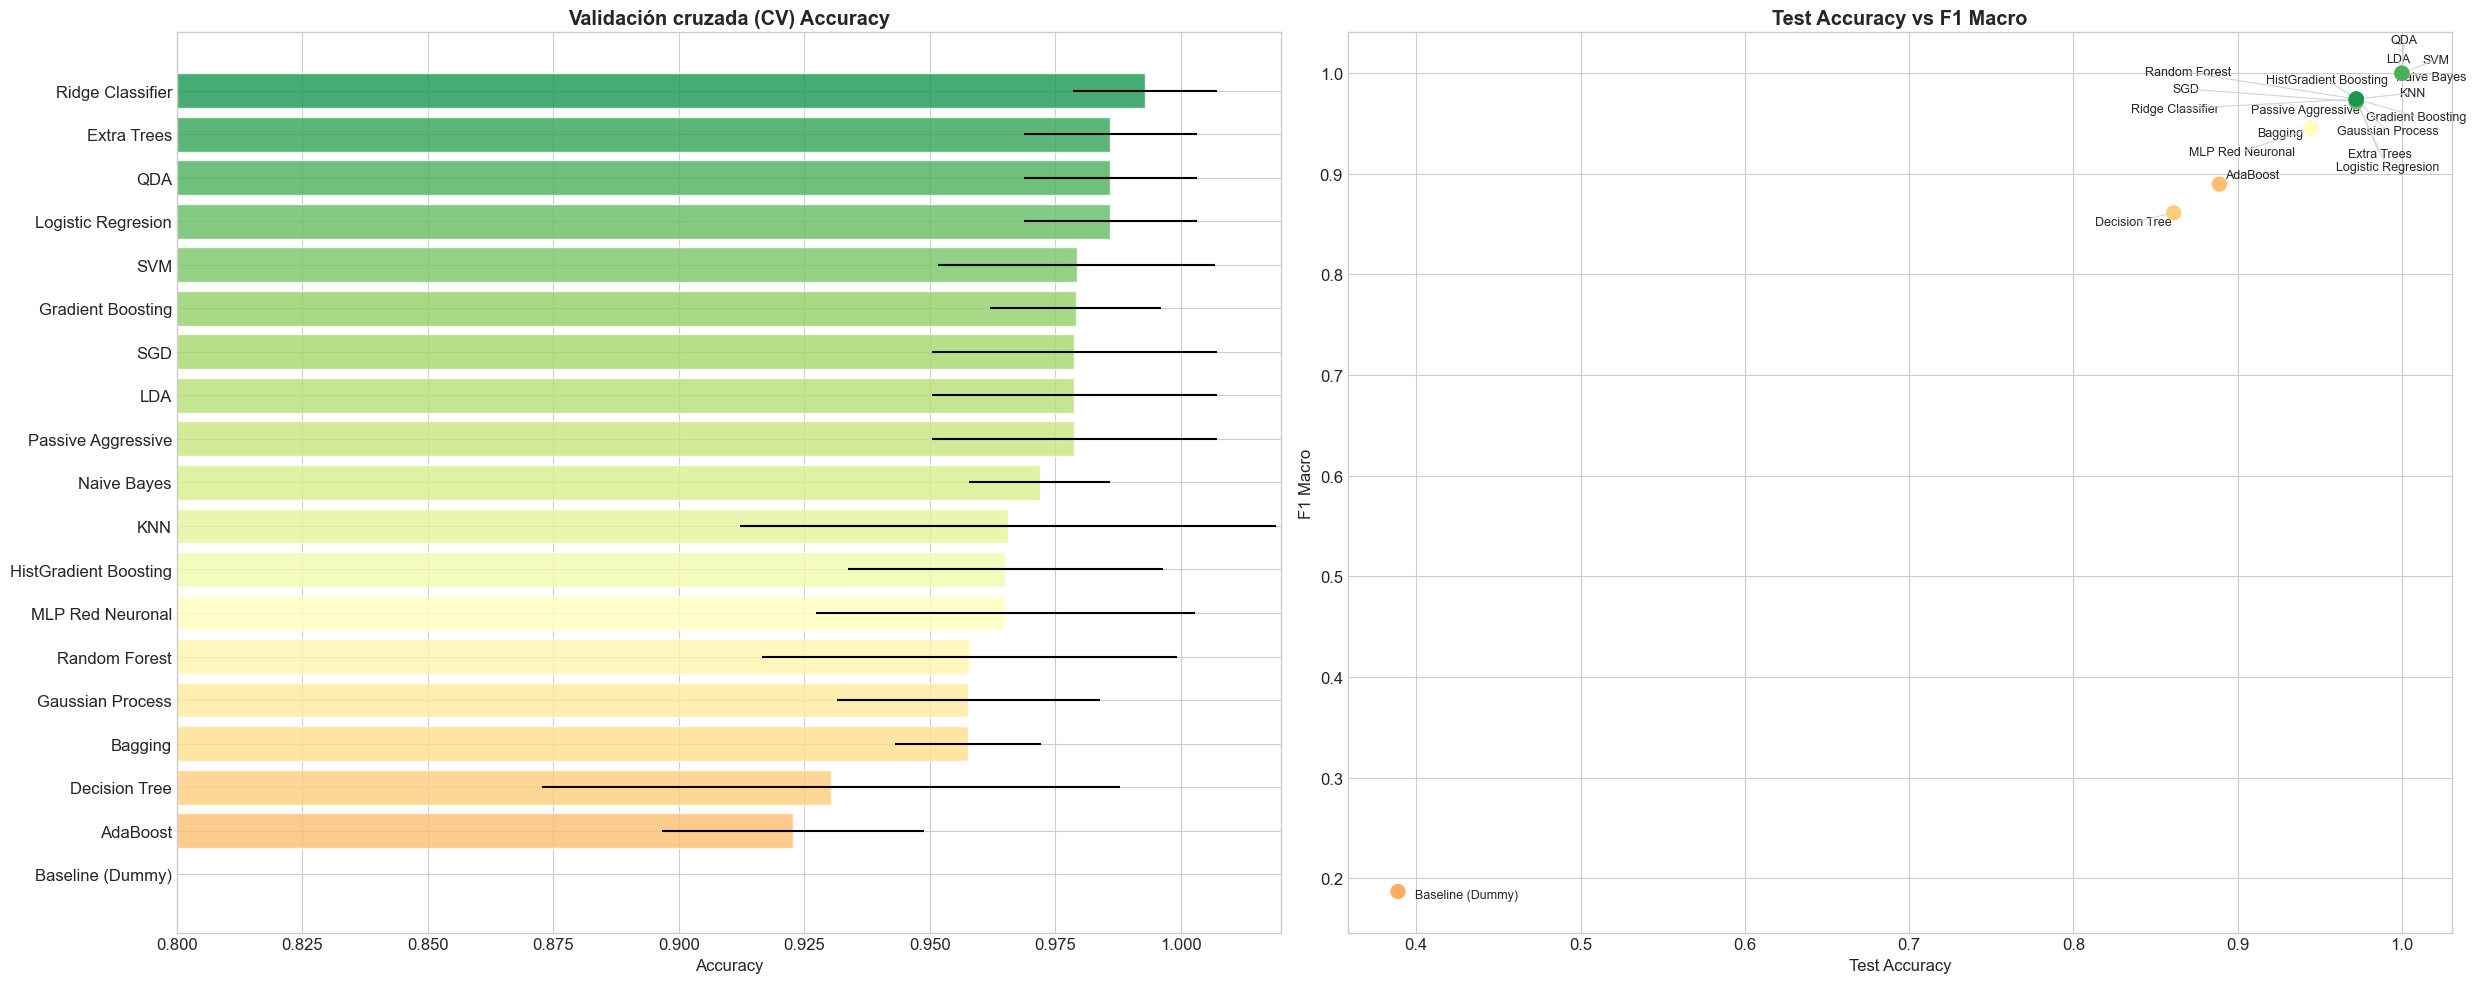

In [92]:
fig, ax = plt.subplots(1, 2, figsize=(25, 10))

df_plot = df_resultados.sort_values('CV_Mean')
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(df_plot)))

ax[0].barh(df_plot['Modelo'], df_plot['CV_Mean'], xerr=df_plot['CV_Std'], color=colors, alpha=0.8)
ax[0].set_xlabel('Accuracy')
ax[0].set_title('Validación cruzada (CV) Accuracy', fontweight='bold')
ax[0].set_xlim(0.80, 1.02)

ax[1].scatter(df_plot['Test_accuracy'], df_plot['F1_Macro'], color=colors, s=100, zorder=5)

textos = []

for _, row in df_plot.iterrows():
    t = ax[1].text(row['Test_accuracy'], row['F1_Macro'], row['Modelo'],
                   fontsize=9, ha='center', va='center')
    textos.append(t)

adjust_text(textos, ax=ax[1],
            arrowprops=dict(arrowstyle="-", color='lightgray', lw=0.8),
            expand_points=(1.5, 1.5))


ax[1].set_xlabel('Test Accuracy')
ax[1].set_ylabel('F1 Macro')
ax[1].set_title('Test Accuracy vs F1 Macro', fontweight='bold')

plt.tight_layout()
plt.show()

In [96]:
top_3 = df_resultados.head(3)['Modelo'].tolist()
top_3

['SVM', 'LDA', 'Naive Bayes']

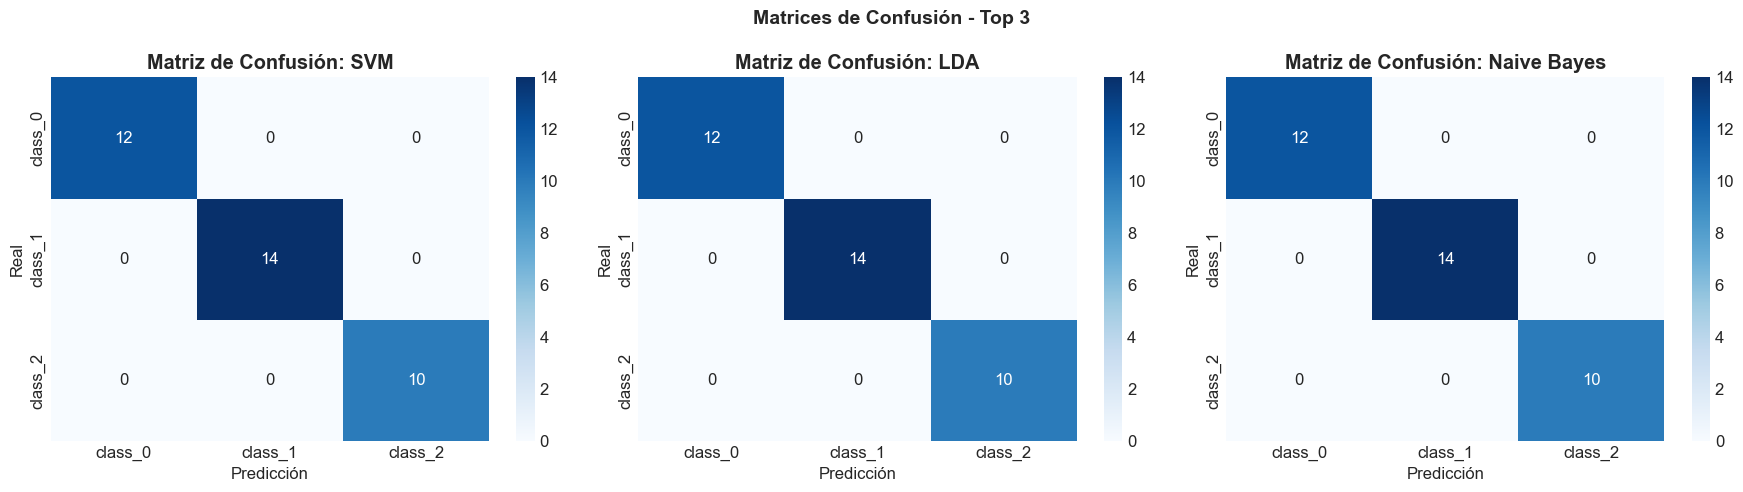

In [103]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, nombre in zip(axes, top_3):
    modelo = modelos[nombre]
    y_pred = modelo.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=wine.target_names, yticklabels=wine.target_names)

    ax.set_title(f'Matriz de Confusión: {nombre}', fontweight='bold')
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
plt.suptitle('Matrices de Confusión - Top 3', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

#